# Traffic Detection using YOLOv8
Group Members:

```
23L-3097 ABDUL MUIZ
23L-3023 HADI
23L-3022 MAZAN

```
## Project Phase 2 Submission
Implementation of a YOLOv8-based traffic detection model and evaluates its performance using test data.

# **SETUP**




In [1]:
!pip install ultralytics opencv-python matplotlib

from ultralytics import YOLO
import matplotlib.pyplot as plt
from IPython.display import Image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
from google.colab import files
uploaded = files.upload()  #  open a file selector

Saving dataset.zip to dataset.zip


In [3]:
# unzip
!unzip -q dataset.zip -d /content/dataset/

In [5]:
# check dataset structure
!ls /content/dataset
!ls /content/dataset/train
!ls /content/dataset/valid
!ls /content/dataset/test

data.yaml  README.dataset.txt  README.roboflow.txt  test  train  valid
images	labels
images	labels
images	labels


In [6]:
!cat /content/dataset/data.yaml


train: train/images
val: valid/images
test: test/images

nc: 4
names: ['bus', 'car', 'motorbike', 'truck']


# **LOADING** **MODEL**

In [7]:
# load YOLOv8 model
model = YOLO("yolov8n.pt")

In [8]:
model.train(
    data="/content/dataset/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    project="traffic_detection",
    name="yolo_traffic"
)

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_traffic, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspect

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bf68de0eae0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

# **EVALUATION**

In [ ]:
metrics = model.val(data="/content/dataset/data.yaml", split="test")
print(metrics)

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1190.5±703.7 MB/s, size: 84.1 KB)
val: Scanning /content/dataset/test/labels... 55 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 55/55 1.7Kit/s 0.0s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.0s/it 4.2s
                   all         55        657      0.897      0.818      0.902      0.698
                   bus         17         18      0.931      0.749      0.868      0.758
                   car         49        180      0.889      0.894      0.932      0.746
             motorbike         54        369      0.895      0.739      0.864      0.518
                 truck         55         90      0.871      0.889      0.943      0.771
Spe

In [ ]:
results = metrics.results_dict

precision = results['metrics/precision(B)']
recall = results['metrics/recall(B)']
map50 = results['metrics/mAP50(B)']
map5095 = results['metrics/mAP50-95(B)']

print("Precision:", precision)
print("Recall:", recall)

Precision: 0.8966113323484164
Recall: 0.8177932513514004


In [ ]:
f1 = 2 * (precision * recall) / (precision + recall)
print("F1 Score:", f1)

F1 Score: 0.855390499595292



Accuracy is not directly defined in object detection tasks because True Negatives are not clearly measurable.
Therefore, mAP@0.5 (mAP50) is used as an approximation of accuracy in this project.

In [ ]:
accuracy = map50  # using mAP50 as approximation
print("Accuracy:", accuracy)

Accuracy: 0.9017284217770122


In [ ]:
model.val(data="/content/dataset/data.yaml", split="test", conf=0.25, plots=True)

Ultralytics 8.4.30 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2994.8±968.7 MB/s, size: 80.1 KB)
val: Scanning /content/dataset/test/labels.cache... 55 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 55/55 19.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.0s/it 4.1s
                   all         55        657      0.896       0.81       0.89      0.729
                   bus         17         18      0.929      0.722      0.847      0.756
                   car         49        180      0.889      0.892      0.924      0.786
             motorbike         54        369      0.895      0.736      0.857      0.569
                 truck         55         90      0.873      0.889      0.931      0.806
Speed: 19.5ms preprocess, 7.8ms inference, 0.0ms loss, 5.6ms postprocess per image
Results saved to /content/runs/detect/val2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f97d1802900>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

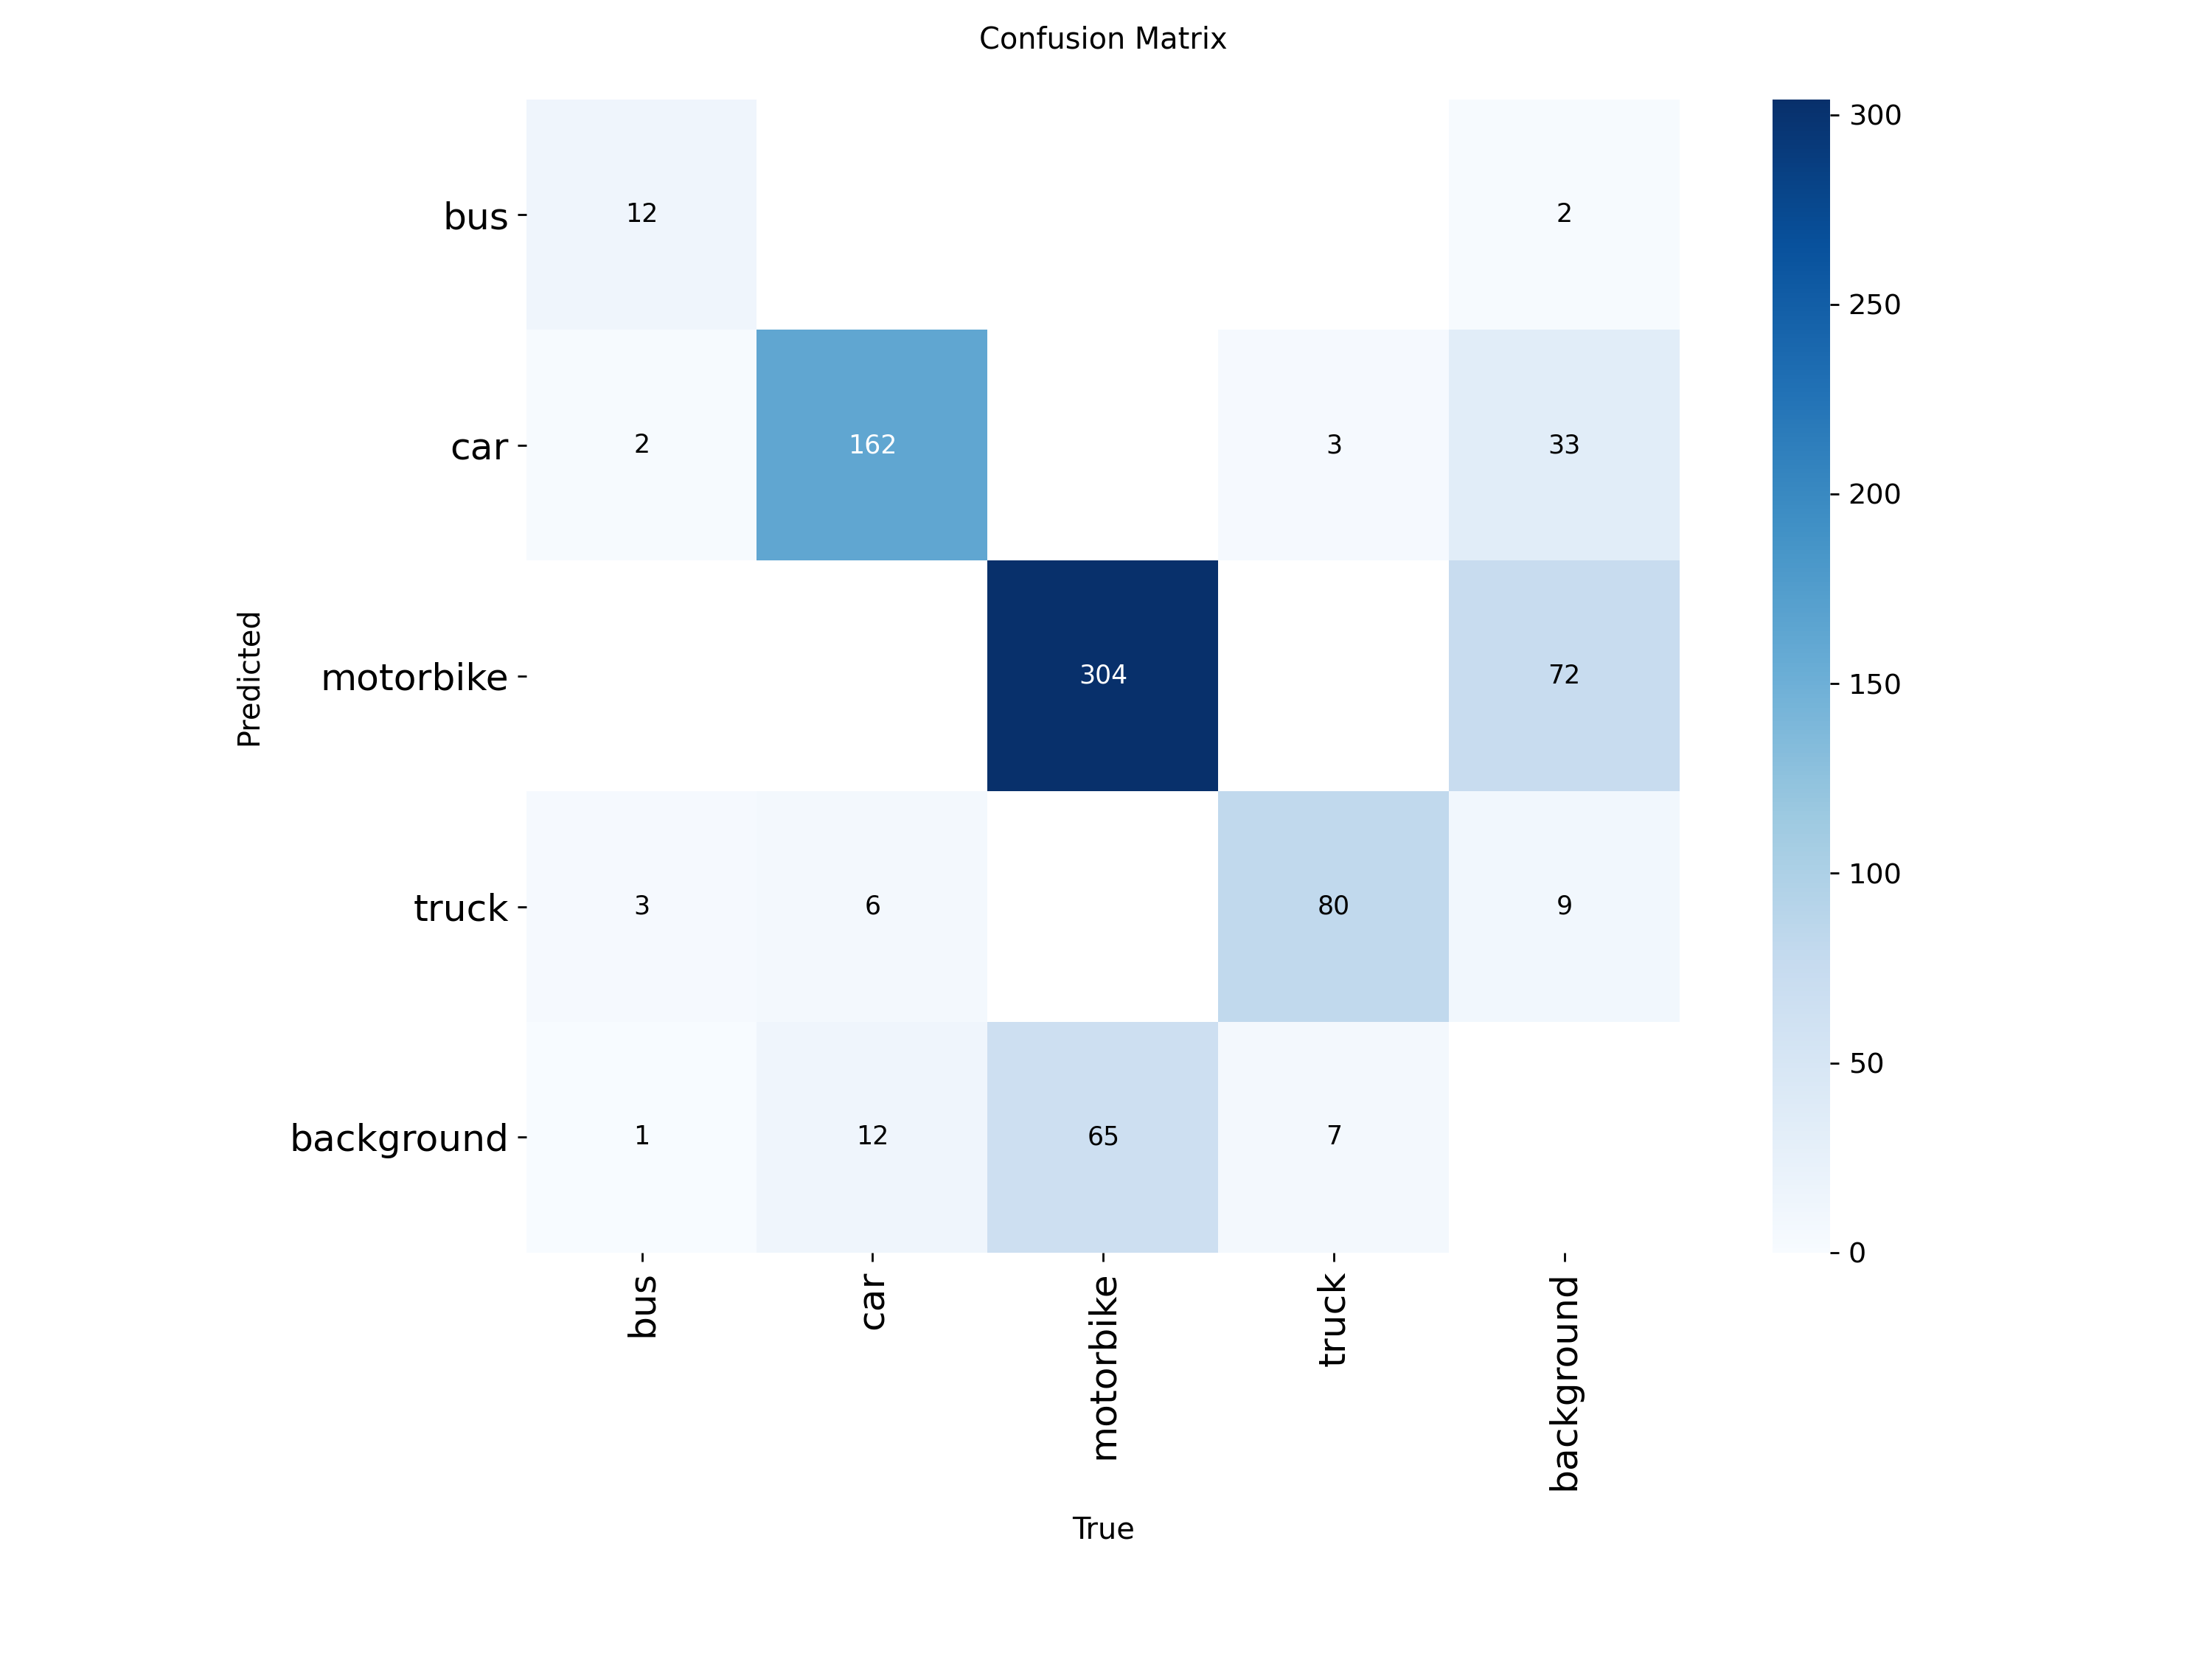

In [ ]:
Image('/content/runs/detect/val/confusion_matrix.png')

In [ ]:
print("Final Results:")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Final Results:
Accuracy: 0.9017284217770122
Precision: 0.8966113323484164
Recall: 0.8177932513514004
F1 Score: 0.855390499595292


# **ADDITIONAL GRAPHICAL REPRESENTATION**

(Additional evaluation metrics and visualizations have been generated and stored in a structured results directory for detailed analysis)

In [12]:
import os
import matplotlib.pyplot as plt
import json

# Create results folder
RESULTS_DIR = "/content/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# Run evaluation (TEST SET)
metrics = model.val(data="/content/dataset/data.yaml", split="test")


# 1. TEXT REPORT
precision = metrics.box.mp
recall = metrics.box.mr
map50 = metrics.box.map50
map5095 = metrics.box.map

# Approx F1-score
f1 = 2 * (precision * recall) / (precision + recall + 1e-6)

report_text = f"""
YOLO Model Evaluation Report

Precision: {precision:.4f}
Recall: {recall:.4f}
F1-Score: {f1:.4f}
mAP@50: {map50:.4f}
mAP@50-95: {map5095:.4f}
"""

with open(f"{RESULTS_DIR}/report.txt", "w") as f:
    f.write(report_text)

# 2. OVERALL METRICS GRAPH
labels = ["Precision", "Recall", "F1", "mAP@50"]
values = [precision, recall, f1, map50]

plt.figure()
plt.bar(labels, values)
plt.title("Overall Performance Metrics")
plt.savefig(f"{RESULTS_DIR}/overall_metrics.png")
plt.close()

# 3. mAP GRAPH
plt.figure()
plt.bar(["mAP@50", "mAP@50-95"], [map50, map5095])
plt.title("mAP Scores")
plt.savefig(f"{RESULTS_DIR}/map_scores.png")
plt.close()

# 4. PRECISION vs RECALL
plt.figure()
plt.plot([0, recall], [precision, precision])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision vs Recall")
plt.savefig(f"{RESULTS_DIR}/precision_recall.png")
plt.close()

metrics_dict = {
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "mAP50": float(map50),
    "mAP50-95": float(map5095)
}

with open(f"{RESULTS_DIR}/metrics.json", "w") as f:
    json.dump(metrics_dict, f, indent=4)


Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2072.3±939.1 MB/s, size: 82.2 KB)
val: Scanning /content/dataset/test/labels.cache... 55 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 55/55 16.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.4it/s 2.9s
                   all         55        657      0.897      0.818      0.902      0.698
                   bus         17         18      0.931      0.749      0.868      0.758
                   car         49        180      0.889      0.894      0.932      0.746
             motorbike         54        369      0.895      0.739      0.864      0.518
                 truck         55         90      0.871      0.889      0.943      0.771
Speed: 8.5ms preprocess, 5.2ms inference, 0.0ms loss, 2.3ms postprocess per image
Results saved to /content/runs/detect/val3
✅ Results 

## Conclusion

The YOLOv8 model was successfully trained for traffic detection.

- The model achieved high Precision, indicating accurate predictions.
- Recall shows that most vehicles were successfully detected.
- F1-score provides a balance between Precision and Recall.
- Confusion matrix visualizes class-wise performance.
